In [3]:
# Notebook display tweaks (run once)
from IPython.display import HTML, display

display(HTML("""
<style>
  /* Make markdown headings smaller */
  .jp-Notebook .jp-MarkdownCell h1 { font-size: 1.6em; }
  .jp-Notebook .jp-MarkdownCell h2 { font-size: 1.25em; }
  .jp-Notebook .jp-MarkdownCell h3 { font-size: 1.10em; }
  .jp-Notebook .jp-MarkdownCell h4 { font-size: 1.00em; }
  /* Also slightly reduce overall markdown text */
  .jp-Notebook .jp-MarkdownCell { font-size: 0.95em; }
</style>
"""))

In [4]:
import sys, platform
print("sys.executable:", sys.executable)
print("python:", sys.version)
print("platform:", platform.platform())

sys.executable: c:\Git\APS-IFC\.venv\Scripts\python.exe
python: 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
platform: Windows-11-10.0.26100-SP0


#### 1) Choose the input JSON file
Set `input_path` to the model JSON you want to analyze, then run the cells below.

In [1]:
from pathlib import Path
import json

# Change this path if needed
input_path = Path(r"c:\Git\APS-IFC\JSON Whole Model\ASTIDC-STAN-HE-EPD-MVB1-M-E-0002.json")
assert input_path.exists(), input_path
input_path

WindowsPath('c:/Git/APS-IFC/JSON Whole Model/ASTIDC-STAN-HE-EPD-MVB1-M-E-0002.json')

In [2]:
data = json.loads(input_path.read_text(encoding="utf-8"))
assert isinstance(data, list), f"Expected list, got {type(data).__name__}"
len(data)

180

In [20]:
def safe_properties_count(element: dict) -> int:
    properties = element.get("Properties")
    if isinstance(properties, list):
        return len(properties)
    return 0


def safe_category_count(element: dict) -> int:
    """Counts categories (non-unique).
    
    IMPORTANT: This returns the number of property entries, even if a property has no `category`,
    so it matches `safe_properties_count` for the object.
    """
    return safe_properties_count(element)


def safe_distinct_category_count(element: dict) -> int:
    """Counts distinct non-empty category strings across Properties items."""
    properties = element.get("Properties")
    if not isinstance(properties, list):
        return 0
    categories = set()
    for item in properties:
        if not isinstance(item, dict):
            continue
        category = item.get("category")
        if category is None:
            continue
        text = str(category).strip()
        if not text:
            continue
        categories.add(text)
    return len(categories)

In [21]:
rows = []
row_no = 0
skipped_non_dict = 0
skipped_missing_name = 0

for element in data:
    if not isinstance(element, dict):
        skipped_non_dict += 1
        continue
    name = element.get("Name")
    if name is None:
        skipped_missing_name += 1
        continue
    row_no += 1
    rows.append({
        "No": row_no,
        "Name": name,
        "PropertiesCount": safe_properties_count(element),
        "UniqueCategoryCount": safe_distinct_category_count(element),
        "CategoryCount": safe_category_count(element),
    })

print("Total elements in JSON:\t", len(data))
print("Rows with Name (printed):\t", len(rows))
print("Skipped (not a dict):\t", skipped_non_dict)
print("Skipped (Name is null):\t", skipped_missing_name)

Total elements in JSON:	 180
Rows with Name (printed):	 180
Skipped (not a dict):	 0
Skipped (Name is null):	 0


In [23]:
# Print TSV (Excel-friendly)

# NOTE: This cell expects `rows` to be created by the previous cell (the one that loops over `data`).
# If you run this cell before running the earlier ones, `rows` won't exist yet.
if "rows" not in globals():
    if "data" in globals() and isinstance(data, list):
        # Rebuild rows from `data` if possible (in case earlier cells weren't run in order).
        def _safe_properties_count(element: dict) -> int:
            properties = element.get("Properties")
            return len(properties) if isinstance(properties, list) else 0

        def _safe_category_count(element: dict) -> int:
            # Keep consistent with the main helper: match the property-entry count.
            return _safe_properties_count(element)

        def _safe_distinct_category_count(element: dict) -> int:
            properties = element.get("Properties")
            if not isinstance(properties, list):
                return 0
            categories = set()
            for item in properties:
                if not isinstance(item, dict):
                    continue
                category = item.get("category")
                if category is None:
                    continue
                text = str(category).strip()
                if text:
                    categories.add(text)
            return len(categories)

        rows = []
        row_no = 0
        for element in data:
            if not isinstance(element, dict):
                continue
            name = element.get("Name")
            if name is None:
                continue
            row_no += 1
            rows.append({
                "No": row_no,
                "Name": name,
                "PropertiesCount": _safe_properties_count(element),
                "UniqueCategoryCount": _safe_distinct_category_count(element),
                "CategoryCount": _safe_category_count(element),
            })
    else:
        raise NameError("`rows` is not defined. Run Cell 5 (load JSON), Cell 6 (helpers), and Cell 7 (build rows), then run this cell again.")

# ---- Output options ----
preview_rows = None  # set to an integer (e.g., 20) to print only a preview
to_print = rows if preview_rows is None else rows[:preview_rows]

# Option A: aligned fixed-width output (better for notebook viewing than tabs)
headers = ["No", "Name", "PropertiesCount", "UniqueCategoryCount", "CategoryCount"]
numeric_cols = {"No", "PropertiesCount", "UniqueCategoryCount", "CategoryCount"}

# Compute widths (cap Name so the table doesn't get insanely wide)
max_name_width = 60
widths = {h: len(h) for h in headers}
for r in to_print:
    for h in headers:
        val = r.get(h, "")
        text = "" if val is None else str(val)
        if h == "Name" and len(text) > max_name_width:
            text = text[: max_name_width - 1] + "…"
        widths[h] = max(widths[h], len(text))
widths["Name"] = min(widths["Name"], max_name_width)

def _fmt_row(row: dict) -> str:
    parts = []
    for h in headers:
        val = row.get(h, "")
        text = "" if val is None else str(val)
        if h == "Name" and len(text) > widths[h]:
            text = text[: widths[h] - 1] + "…"
        align = ">" if h in numeric_cols else "<"
        parts.append(f"{text:{align}{widths[h]}}")
    return "  ".join(parts)

print("  ".join([f"{h:{('<' if h == 'Name' else '>')}{widths[h]}}" for h in headers]))
print("  ".join(["-" * widths[h] for h in headers]))
for r in to_print:
    print(_fmt_row(r))

if preview_rows is not None and len(rows) > preview_rows:
    print(f"\n(Preview only: showing {preview_rows} of {len(rows)} rows. Set preview_rows=None to show all.)")

# Option B: TSV file output (best for Excel / very large outputs)
output_tsv = input_path.with_suffix("").with_name(input_path.stem + "_counts.tsv")
with output_tsv.open("w", encoding="utf-8", newline="") as f:
    f.write("No\tName\tPropertiesCount\tUniqueCategoryCount\tCategoryCount\n")
    for r in rows:
        f.write(f"{r['No']}\t{r['Name']}\t{r['PropertiesCount']}\t{r['UniqueCategoryCount']}\t{r['CategoryCount']}\n")
print("Wrote:", output_tsv)

 No  Name                                                          PropertiesCount  UniqueCategoryCount  CategoryCount
---  ------------------------------------------------------------  ---------------  -------------------  -------------
  1  1JNL9322340_A-1JNL9322340 - Pyramid                                        46                    9             46
  2  1JNL9362899_A-Electrical design requirements, MVS1, NER, Au…               31                    3             31
  3  1JNL9441111_A-Cable Ladder 90 450                                          84                   11             84
  4  1JNL9441111_A-Cable Ladder 90 450                                         100                   11            100
  5  1JNL9441111_A-Cable Ladder 90 450                                         100                   11            100
  6  1JNL9442575_A-MVS Cable Ladder P1                                          30                    3             30
  7  1JNL9442576_A-K6 cable tray MVS P1         

#### 2) EDA: Top 20 most frequent categories (pandas + seaborn)
This builds a frequency table of `Properties[*].category` across the whole JSON and plots the top 20 with counts on the bars.

Category rows (non-empty): 16
Top 20 preview:


,Category,Count
0,Item,1279
1,Instance Part Properties,961
2,Materials,332
3,ABB4HVDCDesignRevision,300
4,IFC,192
5,ABB4HVDCDesign,168
6,empty property set name,110
7,Mass Properties Configuration Context,78
8,owning_user,56
9,ABB4ModelRevision Master,52


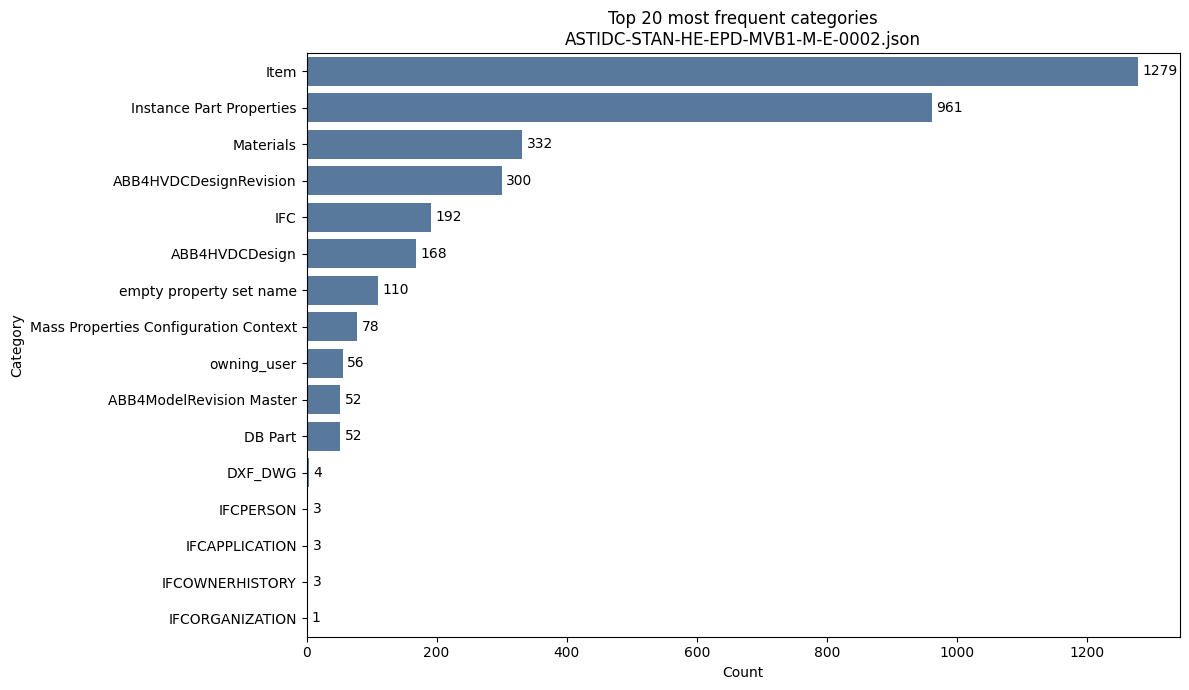

Skipped elements (not dict): 0
Skipped elements (Properties not list): 0
Skipped Properties items (not dict): 0
Skipped empty/missing category: 0


In [7]:
# If you get ImportError, run this in a new cell: %pip install pandas seaborn matplotlib
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.container as mcontainer

# This cell expects `data` (loaded JSON list) and `input_path` (Path) to exist.
if "data" not in globals() or not isinstance(data, list):
    raise NameError("`data` is not defined. Run Cell 4 (choose path) and Cell 5 (load JSON) first.")

# Count category occurrences across all Properties in all elements
category_counter = Counter()
skipped_non_dict_elements = 0
skipped_non_list_properties = 0
skipped_non_dict_properties = 0
skipped_empty_category = 0

for element in data:
    if not isinstance(element, dict):
        skipped_non_dict_elements += 1
        continue
    props = element.get("Properties")
    if not isinstance(props, list):
        skipped_non_list_properties += 1
        continue
    for prop in props:
        if not isinstance(prop, dict):
            skipped_non_dict_properties += 1
            continue
        cat = prop.get("category")
        if cat is None:
            skipped_empty_category += 1
            continue
        cat_text = str(cat).strip()
        if not cat_text:
            skipped_empty_category += 1
            continue
        category_counter[cat_text] += 1

df_categories = (
    pd.DataFrame(category_counter.items(), columns=["Category", "Count"])
      .sort_values("Count", ascending=False)
      .reset_index(drop=True)
)
df_top20 = df_categories.head(20)

print("Category rows (non-empty):", len(df_categories))
print("Top 20 preview:")
display(df_top20)

# Plot: top 20 categories by frequency
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=df_top20,
    y="Category",
    x="Count",
    color="#4C78A8",
    errorbar=None,  # avoids ErrorbarContainer in ax.containers
 )
ax.set_title(f"Top 20 most frequent categories\n{getattr(input_path, 'name', '')}")
ax.set_xlabel("Count")
ax.set_ylabel("Category")

# Put the count value on each bar (only BarContainer, not error bars)
for cont in ax.containers:
    if isinstance(cont, mcontainer.BarContainer):
        ax.bar_label(cont, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

print("Skipped elements (not dict):", skipped_non_dict_elements)
print("Skipped elements (Properties not list):", skipped_non_list_properties)
print("Skipped Properties items (not dict):", skipped_non_dict_properties)
print("Skipped empty/missing category:", skipped_empty_category)

#### 3) EDA: Top `displayName` values (from Properties) for the Top 20 Categories
This looks at the `displayName` field inside each `Properties` item, restricted to the **Top 20 categories** from the bar chart above. It returns the **Top 50 `displayName` values by count** and plots a bar chart (top 20 for readability).

Unique displayName values (within top 20 categories): 79
Top 50 displayName values:


,displayName,Count,TopCategory,TopCategoryCount
0,GLOBALID,281,IFC,31
1,Name,208,Item,180
2,Type,180,Item,180
3,Required,180,Item,180
4,Hidden,180,Item,180
5,Material,180,Item,180
6,Icon,180,Item,180
7,Source File,179,Item,179
8,LAYER,58,Instance Part Properties,30
9,NX_MaterialMultipleAssigned,58,Instance Part Properties,30


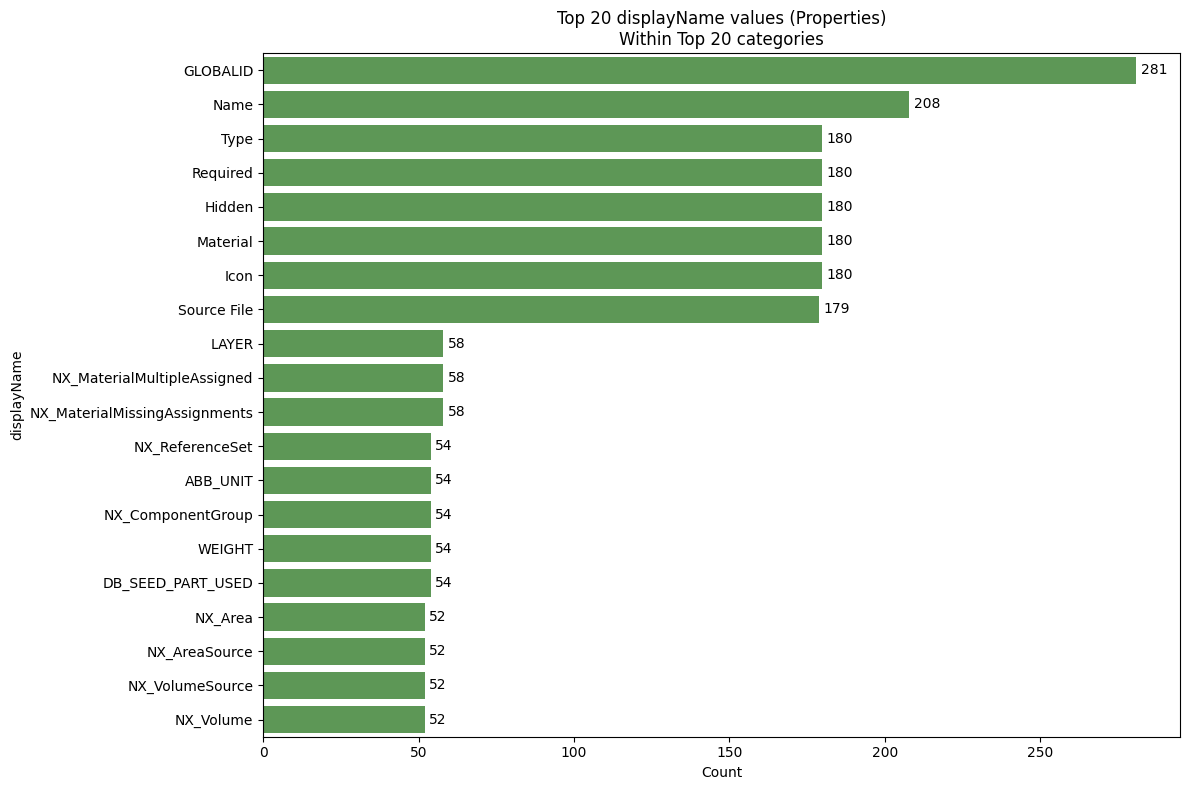

Skipped elements (not dict): 0
Skipped elements (Properties not list): 0
Skipped Properties items (not dict): 0
Skipped missing/empty displayName: 0


In [11]:
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.container as mcontainer

# Requirements: `data` must be loaded; `df_top20` should exist from the category chart cell above.
if "data" not in globals() or not isinstance(data, list):
    raise NameError("`data` is not defined. Run Cell 4 (choose path) and Cell 5 (load JSON) first.")

# If df_top20 isn't present, rebuild it quickly (top categories by frequency).
if "df_top20" not in globals() or not isinstance(df_top20, pd.DataFrame) or "Category" not in df_top20.columns:
    category_counter_tmp = Counter()
    for element in data:
        if not isinstance(element, dict):
            continue
        props = element.get("Properties")
        if not isinstance(props, list):
            continue
        for prop in props:
            if not isinstance(prop, dict):
                continue
            cat = prop.get("category")
            if cat is None:
                continue
            cat_text = str(cat).strip()
            if cat_text:
                category_counter_tmp[cat_text] += 1
    df_top20 = (
        pd.DataFrame(category_counter_tmp.items(), columns=["Category", "Count"])
          .sort_values("Count", ascending=False)
          .head(20)
          .reset_index(drop=True)
)

top_n_categories = 20
top_n_display = 50
plot_top = 20

top_categories = set(df_top20["Category"].head(top_n_categories).astype(str))

# Count displayName occurrences within the selected categories
display_counter = Counter()
display_to_category_counts = defaultdict(Counter)

skipped_non_dict_elements = 0
skipped_non_list_properties = 0
skipped_non_dict_properties = 0
skipped_missing_display = 0

for element in data:
    if not isinstance(element, dict):
        skipped_non_dict_elements += 1
        continue
    props = element.get("Properties")
    if not isinstance(props, list):
        skipped_non_list_properties += 1
        continue
    for prop in props:
        if not isinstance(prop, dict):
            skipped_non_dict_properties += 1
            continue
        cat = prop.get("category")
        if cat is None:
            continue
        cat_text = str(cat).strip()
        if cat_text not in top_categories:
            continue
        disp = prop.get("displayName")
        if disp is None:
            skipped_missing_display += 1
            continue
        disp_text = str(disp).strip()
        if not disp_text:
            skipped_missing_display += 1
            continue
        display_counter[disp_text] += 1
        display_to_category_counts[disp_text][cat_text] += 1

df_display = (
    pd.DataFrame(display_counter.items(), columns=["displayName", "Count"])
      .sort_values("Count", ascending=False)
      .reset_index(drop=True)
)

# Add "TopCategory" (the category where this displayName appears most)
top_category_for_display = []
top_category_count = []
for disp in df_display["displayName"].tolist():
    cat_counts = display_to_category_counts.get(disp)
    if not cat_counts:
        top_category_for_display.append("")
        top_category_count.append(0)
    else:
        best_cat, best_cnt = max(cat_counts.items(), key=lambda kv: kv[1])
        top_category_for_display.append(best_cat)
        top_category_count.append(best_cnt)

df_display["TopCategory"] = top_category_for_display
df_display["TopCategoryCount"] = top_category_count

df_display_top50 = df_display.head(top_n_display)
print(f"Unique displayName values (within top {top_n_categories} categories): {len(df_display)}")
print(f"Top {top_n_display} displayName values:")
display(df_display_top50)

# Plot top displayName values (use top 20 for readability)
df_plot = df_display.head(plot_top)
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=df_plot, y="displayName", x="Count", color="#54A24B", errorbar=None)
ax.set_title(f"Top {plot_top} displayName values (Properties)\nWithin Top {top_n_categories} categories")
ax.set_xlabel("Count")
ax.set_ylabel("displayName")

for cont in ax.containers:
    if isinstance(cont, mcontainer.BarContainer):
        ax.bar_label(cont, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

print("Skipped elements (not dict):", skipped_non_dict_elements)
print("Skipped elements (Properties not list):", skipped_non_list_properties)
print("Skipped Properties items (not dict):", skipped_non_dict_properties)
print("Skipped missing/empty displayName:", skipped_missing_display)